### Consigna Problema 2-Automátas Celulares

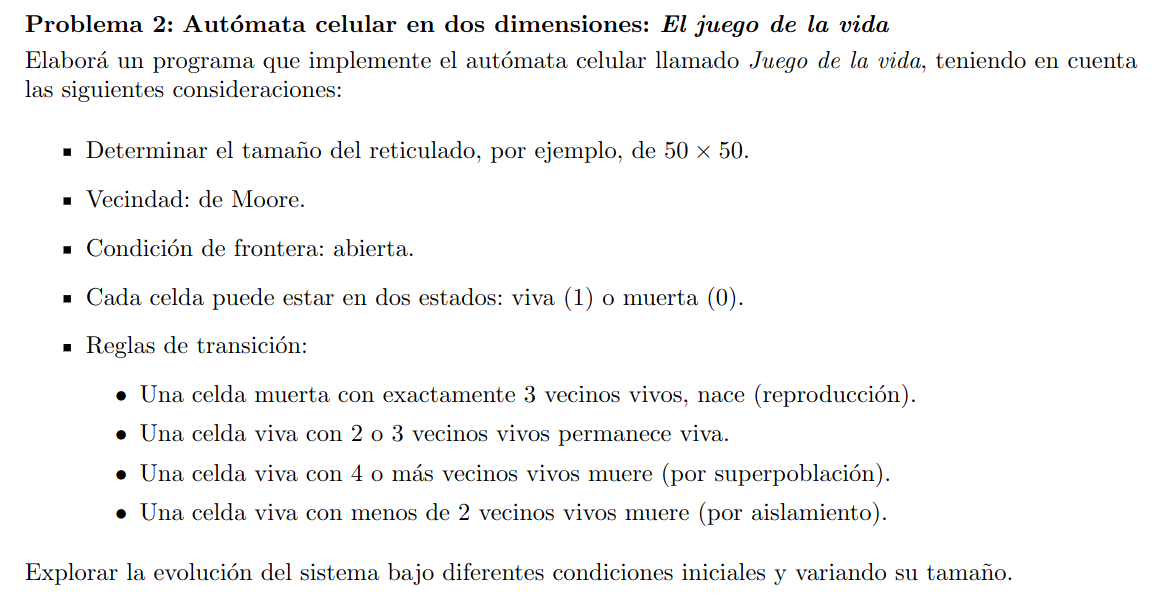

### Resolución

In [9]:
# Importamos librerías
import numpy as np
import random
import matplotlib.pyplot as plt

import matplotlib.animation as animation
from IPython.display import HTML

In [5]:
# Función para crear una matriz de nxn con valores aleatorios en el interior (sin contar bordes)
def gen_ran_matx(n, step=3):
    
    # create a nxn matrix
    matrix = np.zeros((n, n))
    
    # left borders with 0 and assign random values
    for i in range(1, n-1, step): # filas
        for j in range(1, n-1, step): # columnas
            #print(i, j)
            matrix[i, j] = random.randint(0, 1)
            
    return matrix

# Función reglas de decisión
def dec_rules(i, j, c, neighs, matrix_gen):
    
    #print(neighs, neighs[1,1], (neighs.sum()-neighs[1,1]))
    
    if c == 0 and (neighs.sum()-neighs[1,1]) == 3:
        matrix_gen[i, j] = 1
    elif c == 1 and (neighs.sum()-neighs[1,1]) in [2, 3]:
        matrix_gen[i, j] = 1
    elif c == 1 and (neighs.sum()-neighs[1,1]) >= 4:
        matrix_gen[i, j] = 0
    elif c == 1 and (neighs.sum()-neighs[1,1]) < 2:
        matrix_gen[i, j] = 0

# Run juego de la vida
def play_game_life(n, gens, step):
    
    # Generamos matriz t = 0
    matrix_0 = gen_ran_matx(n, step)
    
    # Generamos copia del estado t = 0
    matrix_gen = matrix_0.copy()
    
    # Create empty 3D array (gens, n, n)
    gens_i = 0
    matrix_full_gens = np.empty((gens, n, n), dtype=int)
    matrix_full_gens[gens_i, :, :] = matrix_gen # Fill with t=0 data
    
    # --
    for g in range(gens-1):
        next_gen = matrix_gen.copy()
        for i in range(1, n-1):
            for j in range(1, n-1):
                c = matrix_gen[i, j] # c state t-1
                c_neigh = matrix_gen[i-1:i+2, j-1:j+2] # neighbours t-1
                dec_rules(i, j, c, c_neigh, next_gen) # update t
                
        # Actualizamos 3D array
        gens_i += 1
        matrix_full_gens[gens_i, :, :] = next_gen
        
        # Sobreescribimos matrix_gen para la siguiente generación
        matrix_gen = next_gen 
                
        
    return matrix_0, matrix_gen, matrix_full_gens

In [10]:
# Definimos conficiones iniciales
N = 50
GENS = 50
STEP = 1

# Run Juego de la vida
matrix_0, matrix_gen, matrix_full_gens = play_game_life(N, GENS, STEP)

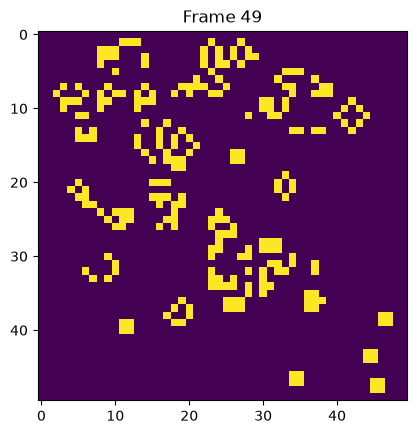

In [11]:
# Generación de la animación 

data = matrix_full_gens.copy()
GENS = data.shape[0]

fig, ax = plt.subplots()
im = ax.imshow(data[0], cmap='viridis', animated=True, vmin=0, vmax=1)
title = ax.set_title("Frame 0")

def update(frame_idx):
    im.set_array(data[frame_idx])
    title.set_text(f"Frame {frame_idx}")
    return [im, title]

ani = animation.FuncAnimation(
    fig, update, frames=GENS, interval=200, blit=True
)

HTML(ani.to_jshtml())  # for Jupyter notebooks

In [726]:
data.shape

(50, 10, 10)

In [720]:
data.shape

(10, 10, 50)